In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# 1. Carga de datos
df_long = pd.read_csv('df_long.csv')
df_resumen = pd.read_csv('Base_Resumen_Sujetos.csv')


Mediana NDC Score: 4.666666666666667
Clasificación NDC completada.
Low NDC     70
High NDC    48
Name: NDC_Group, dtype: int64
Grupos encontrados en expectativa_sin_num: [-1, 0, 1]

 ANÁLISIS PARA: expectativa_sin_num = -1


C:\Users\felip\anaconda3\lib\site-packages\seaborn\categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)
C:\Users\felip\anaconda3\lib\site-packages\seaborn\categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)


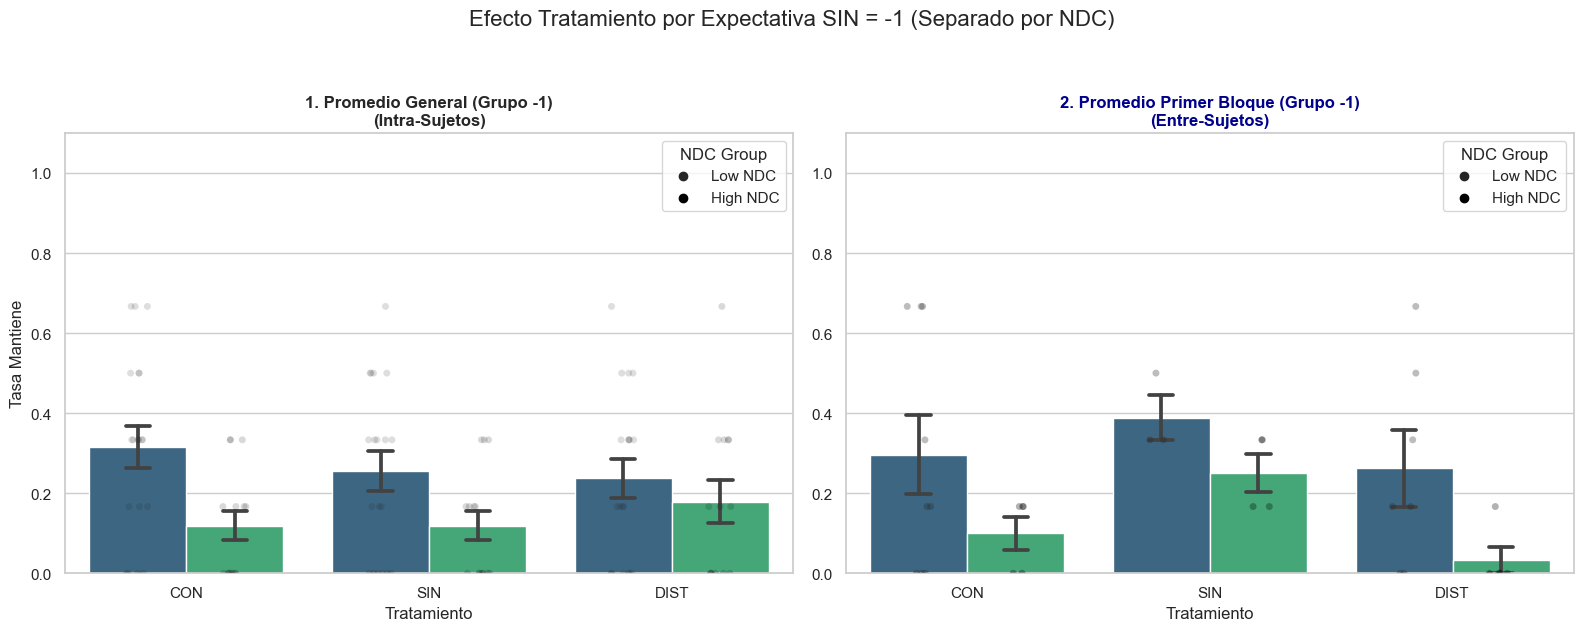

--- RESULTADOS GRUPO -1 (Desglosado por NDC) ---

1. Intra-sujetos (Resumen):
                       count   mean    sem
Tratamiento NDC_Group                     
CON         High NDC      14  0.119  0.037
            Low NDC       19  0.316  0.052
SIN         High NDC      14  0.119  0.037
            Low NDC       19  0.254  0.050
DIST        High NDC      14  0.179  0.054
            Low NDC       19  0.237  0.048

2. Entre-sujetos (Primer Bloque):
                       count   mean    sem
Tratamiento NDC_Group                     
CON         High NDC       5  0.100  0.041
            Low NDC        9  0.296  0.099
SIN         High NDC       4  0.250  0.048
            Low NDC        3  0.389  0.056
DIST        High NDC       5  0.033  0.033
            Low NDC        7  0.262  0.095



 ANÁLISIS PARA: expectativa_sin_num = 0


C:\Users\felip\anaconda3\lib\site-packages\seaborn\categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)
C:\Users\felip\anaconda3\lib\site-packages\seaborn\categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)


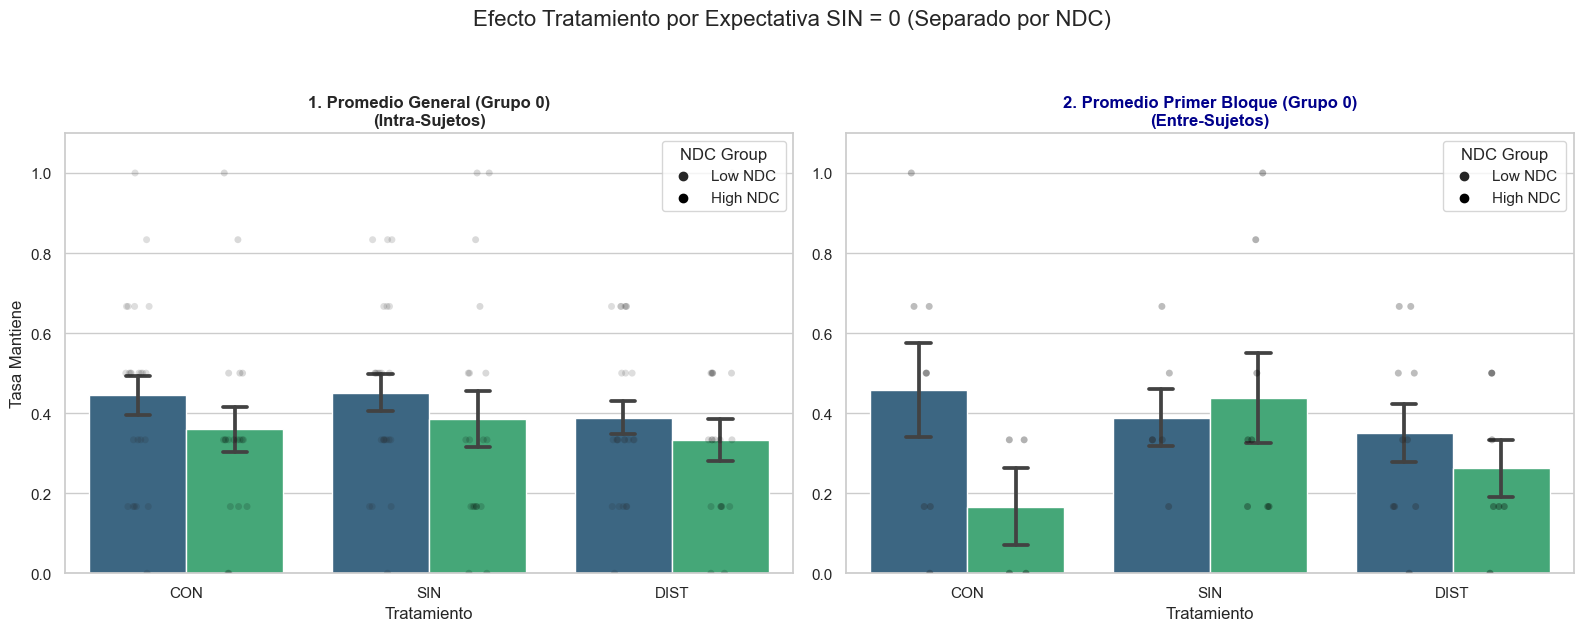

--- RESULTADOS GRUPO 0 (Desglosado por NDC) ---

1. Intra-sujetos (Resumen):
                       count   mean    sem
Tratamiento NDC_Group                     
CON         High NDC      19  0.360  0.056
            Low NDC       24  0.444  0.049
SIN         High NDC      19  0.386  0.070
            Low NDC       24  0.451  0.045
DIST        High NDC      19  0.333  0.053
            Low NDC       24  0.389  0.041

2. Entre-sujetos (Primer Bloque):
                       count   mean    sem
Tratamiento NDC_Group                     
CON         High NDC       4  0.167  0.096
            Low NDC        8  0.458  0.117
SIN         High NDC       8  0.437  0.113
            Low NDC        6  0.389  0.070
DIST        High NDC       7  0.262  0.071
            Low NDC       10  0.350  0.072



 ANÁLISIS PARA: expectativa_sin_num = 1


C:\Users\felip\anaconda3\lib\site-packages\seaborn\categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)
C:\Users\felip\anaconda3\lib\site-packages\seaborn\categorical.py:166: FutureWarning: Setting a gradient palette using color= is deprecated and will be removed in version 0.13. Set `palette='dark:black'` for same effect.
  warnings.warn(msg, FutureWarning)


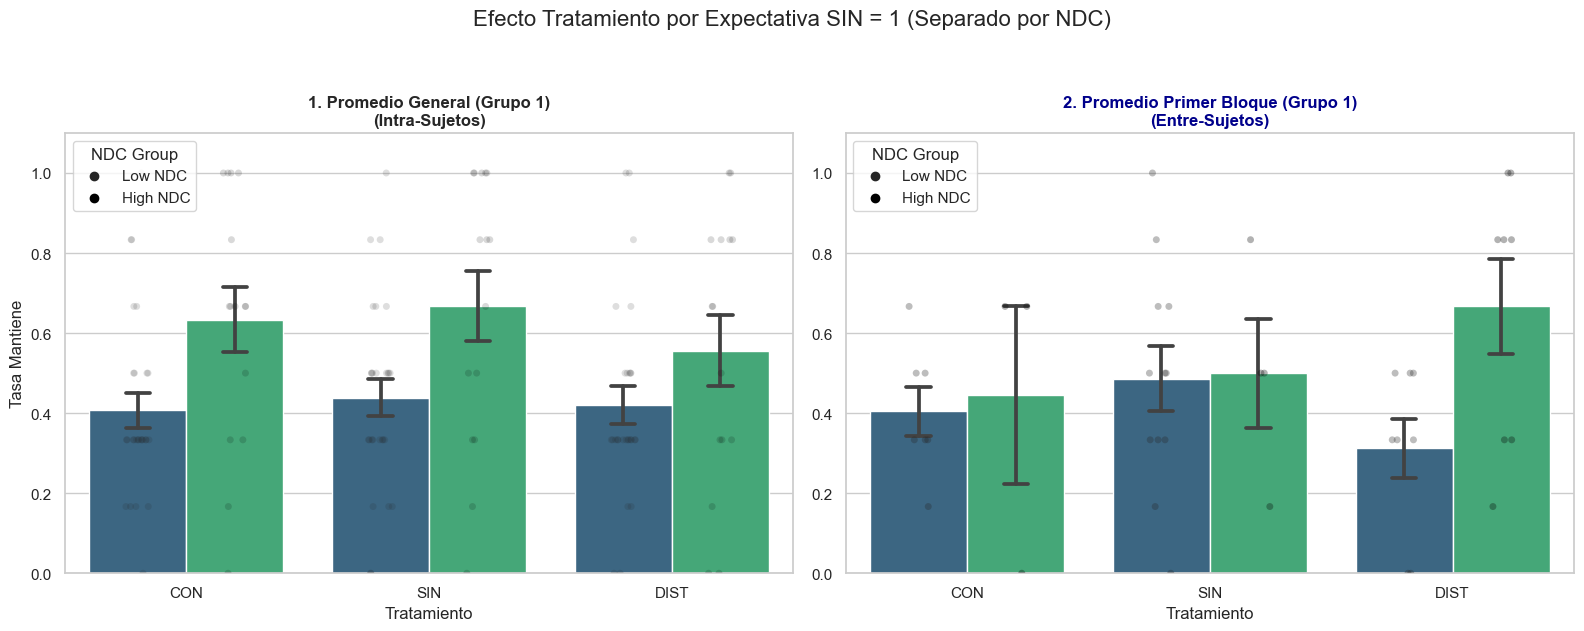

--- RESULTADOS GRUPO 1 (Desglosado por NDC) ---

1. Intra-sujetos (Resumen):
                       count   mean    sem
Tratamiento NDC_Group                     
CON         High NDC      15  0.633  0.082
            Low NDC       27  0.407  0.044
SIN         High NDC      15  0.667  0.088
            Low NDC       27  0.438  0.046
DIST        High NDC      15  0.556  0.089
            Low NDC       27  0.420  0.047

2. Entre-sujetos (Primer Bloque):
                       count   mean    sem
Tratamiento NDC_Group                     
CON         High NDC       3  0.444  0.222
            Low NDC        7  0.405  0.061
SIN         High NDC       4  0.500  0.136
            Low NDC       12  0.486  0.081
DIST        High NDC       8  0.667  0.118
            Low NDC        8  0.312  0.073




In [3]:
# --- LIMPIEZA DE DUPLICADOS EN df_long ---
df_long = df_long.drop_duplicates(subset=['ID_Sujeto', 'Orden_1', 'Orden_2'], keep='first').copy()

# 2. Preprocesamiento
df_long['Tratamiento'] = df_long['Dilema'].str.upper().str.extract('(CON|SIN|DIST)', expand=False)

# --- CLASIFICACIÓN NDC (High vs Low) ---
# Calculamos la mediana basada en los sujetos únicos (usando df_resumen para evitar sesgo por número de filas)
if 'NDC_Score' in df_resumen.columns:
    median_ndc = df_resumen['NDC_Score'].median()
    print(f"Mediana NDC Score: {median_ndc}")

    # Función para clasificar
    def classify_ndc(score):
        return 'High NDC' if score > median_ndc else 'Low NDC'

    # Aplicar a df_resumen
    df_resumen['NDC_Group'] = df_resumen['NDC_Score'].apply(classify_ndc)
    
    # Aplicar a df_long (asegurando que cada sujeto tenga su score, que ya está en df_long)
    df_long['NDC_Group'] = df_long['NDC_Score'].apply(classify_ndc)
    
    print("Clasificación NDC completada.")
    print(df_resumen['NDC_Group'].value_counts())
else:
    print("Error: No se encontró la columna 'NDC_Score'")

# Definir columna de agrupación
col_grupo = 'expectativa_sin_num'

# Verificar que la columna exista
if col_grupo not in df_long.columns:
    print(f"Error: {col_grupo} no está en df_long")
else:
    grupos = sorted(df_long[col_grupo].dropna().unique())
    print(f"Grupos encontrados en {col_grupo}: {grupos}")

    # Iterar por cada grupo
    for grupo in grupos:
        print(f"\n{'='*80}")
        print(f" ANÁLISIS PARA: {col_grupo} = {grupo}")
        print(f"{'='*80}")
        
        # Filtrar df_long para este grupo
        df_long_grupo = df_long[df_long[col_grupo] == grupo].copy()
        ids_grupo = df_long_grupo['ID_Sujeto'].unique()
        
        # Filtrar df_resumen para los mismos sujetos (para consistencia)
        df_resumen_grupo = df_resumen[df_resumen['ID_Sujeto'].isin(ids_grupo)].copy()
        
        # --- PREPARACIÓN DE DATOS ---
        
        # A. Panel 1: Promedio General (Desde df_resumen)
        # Melt, pero mantenemos NDC_Group
        df_panel1 = df_resumen_grupo.melt(
            id_vars=['ID_Sujeto', 'NDC_Group'], 
            value_vars=['Promedio_CON', 'Promedio_SIN', 'Promedio_DIST'],
            var_name='Tratamiento', 
            value_name='Mantiene'
        )
        df_panel1['Tratamiento'] = df_panel1['Tratamiento'].str.replace('Promedio_', '')
        
        # B. Panel 2: Promedio Primer Tratamiento (Desde df_long)
        # Agrupamos por Sujeto, Tratamiento Y NDC_Group
        df_panel2 = df_long_grupo[df_long_grupo['Orden_1'] == 1].groupby(['ID_Sujeto', 'Tratamiento', 'NDC_Group'])['Mantiene'].mean().reset_index()
        
        # --- VISUALIZACIÓN ---
        orden = ['CON', 'SIN', 'DIST']
        hue_order = ['Low NDC', 'High NDC'] # Orden consistente
        sns.set_theme(style="whitegrid")
        
        # Configuramos solo 2 columnas
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        
        # Panel 1
        sns.barplot(data=df_panel1, x='Tratamiento', y='Mantiene', hue='NDC_Group', order=orden, hue_order=hue_order,
                    palette='viridis', errorbar='se', capsize=.1, ax=axes[0])
        sns.stripplot(data=df_panel1, x='Tratamiento', y='Mantiene', hue='NDC_Group', order=orden, hue_order=hue_order,
                      color='black', alpha=0.15, jitter=True, dodge=True, ax=axes[0])
        
        # Limpiar leyenda duplicada del stripplot
        handles, labels = axes[0].get_legend_handles_labels()
        # Tomamos solo los primeros 2 (las barras)
        axes[0].legend(handles[:2], labels[:2], title='NDC Group')
        
        axes[0].set_title(f'1. Promedio General (Grupo {grupo})\n(Intra-Sujetos)', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Tasa Mantiene')
        axes[0].set_ylim(0, 1.1)
        
        # Panel 2
        sns.barplot(data=df_panel2, x='Tratamiento', y='Mantiene', hue='NDC_Group', order=orden, hue_order=hue_order,
                    palette='viridis', errorbar='se', capsize=.1, ax=axes[1])
        sns.stripplot(data=df_panel2, x='Tratamiento', y='Mantiene', hue='NDC_Group', order=orden, hue_order=hue_order,
                      color='black', alpha=0.3, jitter=True, dodge=True, ax=axes[1])
        
        # Limpiar leyenda panel 2
        handles2, labels2 = axes[1].get_legend_handles_labels()
        axes[1].legend(handles2[:2], labels2[:2], title='NDC Group')

        axes[1].set_title(f'2. Promedio Primer Bloque (Grupo {grupo})\n(Entre-Sujetos)', fontsize=12, fontweight='bold', color='darkblue')
        axes[1].set_ylabel('')
        axes[1].set_ylim(0, 1.1)
        
        plt.suptitle(f'Efecto Tratamiento por Expectativa SIN = {grupo} (Separado por NDC)', fontsize=16, y=1.05)
        plt.tight_layout()
        filename = f'panel_doble_expsin_{grupo}_ndc.png'
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        plt.show()
        
        # --- TABLAS ---
        print(f"--- RESULTADOS GRUPO {grupo} (Desglosado por NDC) ---")
        print("\n1. Intra-sujetos (Resumen):")
        print(df_panel1.groupby(['Tratamiento', 'NDC_Group'])['Mantiene'].agg(['count', 'mean', 'sem']).reindex(orden, level=0).round(3))
        
        print("\n2. Entre-sujetos (Primer Bloque):")
        print(df_panel2.groupby(['Tratamiento', 'NDC_Group'])['Mantiene'].agg(['count', 'mean', 'sem']).reindex(orden, level=0).round(3))
        print("\n")

In [5]:
df=df_long
df.columns.tolist()

['ID_Sujeto',
 'Origen_Form',
 'Identidad',
 'Dilema',
 'Orden_1',
 'Bloque',
 'Orden_2',
 'Respuesta',
 'Mantiene',
 'SDO_Score',
 'NDC_Score',
 'expectativa_sin',
 'expectativa_grande',
 'expectativa_pequeña',
 'Genero',
 'politica',
 'nivel_se',
 'Gap_Size',
 'expectativa_sin_num',
 'expectativa_grande_num',
 'expectativa_pequeña_num',
 'Expectativa_Activa',
 'Promedio_Gap_0',
 'Promedio_Gap_1000',
 'Promedio_Gap_1200',
 'Promedio_Gap_2000',
 'Promedio_Gap_2400',
 'Promedio_CON',
 'Promedio_SIN',
 'Promedio_DIST',
 'Delta_Mantiene',
 'Delta_base',
 'Tratamiento',
 'NDC_Group']

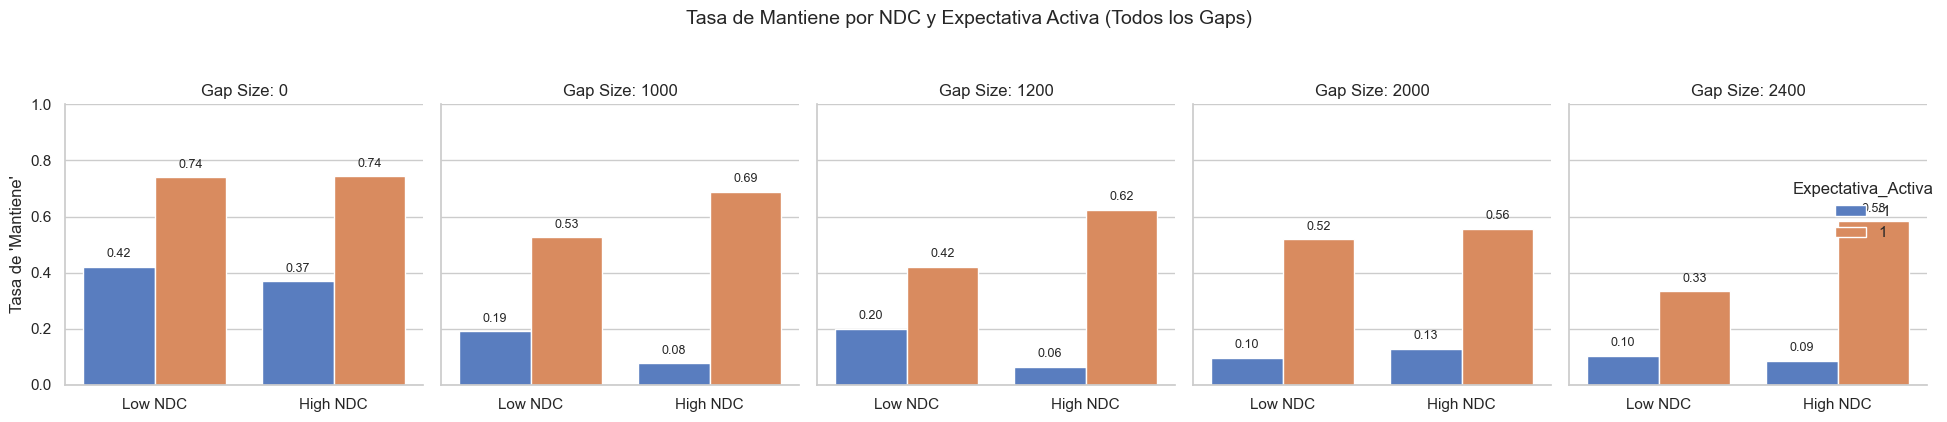

Cantidad de sujetos únicos (N) por grupo:
Expectativa_Activa  -1   1
Gap_Size Nivel_NDC        
0        High NDC   14  15
         Low NDC    19  27
1000     High NDC   26  16
         Low NDC    35  19
1200     High NDC   26  16
         Low NDC    35  19
2000     High NDC   31  12
         Low NDC    45   9
2400     High NDC   31  12
         Low NDC    45   9


In [9]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Crear la categoría High/Low NDC usando el punto de corte
df['Nivel_NDC'] = np.where(df['NDC_Score'] > 4.67, 'High NDC', 'Low NDC')

# 2. Filtrar para usar solo las expectativas 1 y -1 (dejando afuera los 0)
df_plot = df[df['Expectativa_Activa'].isin([1, -1])].copy()

# 3. Generar el gráfico de 5 paneles
# Seaborn calcula automáticamente el promedio de 'mantiene' al agrupar
g = sns.catplot(
    data=df_plot, 
    kind='bar',
    x='Nivel_NDC',            
    y='Mantiene',             # Reemplazá con el nombre de tu columna binaria de decisión
    hue='Expectativa_Activa', 
    col='Gap_Size',           # Usamos la variable experimental de tamaño de gap
    palette='muted',
    height=4, 
    aspect=0.9,
    errorbar=None             # Oculta las barras de error (intervalos de confianza) para que se vea más limpio
)

# 4. Ajustes estéticos 
g.set_axis_labels("", "Tasa de 'Mantiene'")
g.set_titles("Gap Size: {col_name}") 
g.fig.suptitle('Tasa de Mantiene por NDC y Expectativa Activa (Todos los Gaps)', y=1.05, fontsize=14)
g.set(ylim=(0, 1))

# 5. Agregar los valores encima de las barras
for ax in g.axes.ravel():
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(format(p.get_height(), '.2f'), 
                           (p.get_x() + p.get_width() / 2., p.get_height()), 
                           ha = 'center', va = 'center', 
                           xytext = (0, 9), 
                           textcoords = 'offset points',
                           fontsize=9)

plt.tight_layout()
plt.show()

# Agrupamos por las 3 variables y contamos los IDs únicos (nunique)
tabla_sujetos = df_plot.groupby(['Gap_Size', 'Nivel_NDC', 'Expectativa_Activa'])['ID_Sujeto'].nunique().unstack()

# Llenamos los valores vacíos con 0 (por si algún grupo no tiene sujetos)
tabla_sujetos = tabla_sujetos.fillna(0).astype(int)

print("Cantidad de sujetos únicos (N) por grupo:")
print(tabla_sujetos)

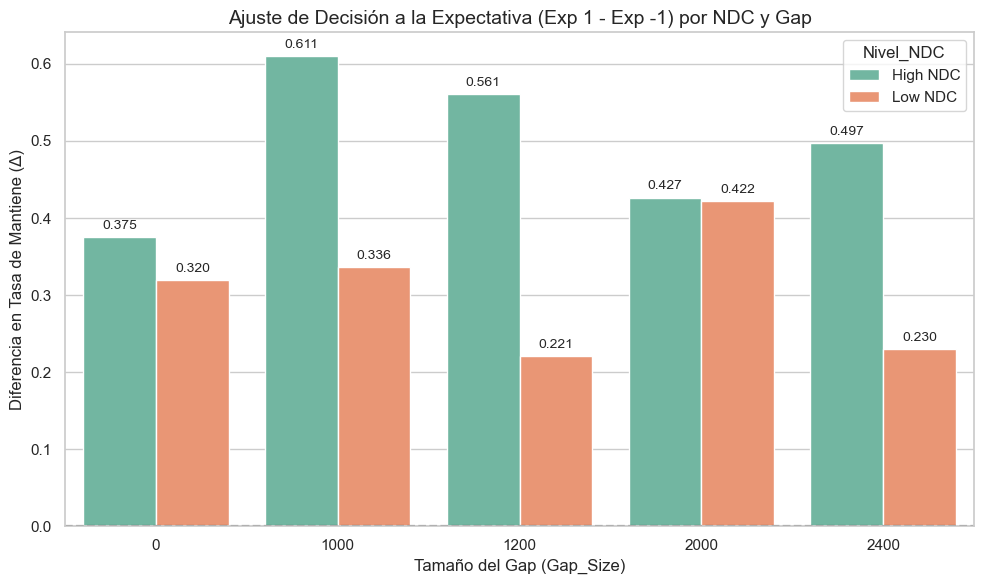

In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generar Mock Data para simular tu escenario

# 2. Filtrar y Categorizar tal como lo definimos
df = df_plot
df['Nivel_NDC'] = np.where(df['NDC_Score'] > 4.67, 'High NDC', 'Low NDC')

# 3. Calcular la tasa promedio de 'mantiene' para cada combinación
tasas = df.groupby(['Gap_Size', 'Nivel_NDC', 'Expectativa_Activa'])['Mantiene'].mean().reset_index()

# 4. Pivotear la tabla para tener las expectativas 1 y -1 en columnas separadas
pivot_df = tasas.pivot(index=['Gap_Size', 'Nivel_NDC'], columns='Expectativa_Activa', values='Mantiene').reset_index()

# 5. Calcular la DIFERENCIA (Ajuste a la expectativa): Tasa Exp 1 - Tasa Exp -1
pivot_df['Diferencia_Tasa'] = pivot_df[1] - pivot_df[-1]

# 6. Graficar
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=pivot_df,
    x='Gap_Size',
    y='Diferencia_Tasa',
    hue='Nivel_NDC',
    palette='Set2'
)

# Títulos y formato
plt.title("Ajuste de Decisión a la Expectativa (Exp 1 - Exp -1) por NDC y Gap", fontsize=14)
plt.ylabel("Diferencia en Tasa de Mantiene (Δ)", fontsize=12)
plt.xlabel("Tamaño del Gap (Gap_Size)", fontsize=12)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5) # Línea en el 0 para referencia

# Etiquetas de datos
for p in ax.patches:
    height = p.get_height()
    if not np.isnan(height):
        # Ajustar posición del texto según si el valor es positivo o negativo
        y_offset = 8 if height >= 0 else -15
        ax.annotate(format(height, '.3f'), 
                       (p.get_x() + p.get_width() / 2., height), 
                       ha = 'center', va = 'center', 
                       xytext = (0, y_offset), 
                       textcoords = 'offset points',
                       fontsize=10)

plt.tight_layout()
plt.savefig('diferencia_expectativas_ndc.png')

--- TABLA DE N (SUJETOS ÚNICOS) ---
 Gap_Size Nivel NDC  Sujetos (Exp 1)  Sujetos (Exp -1)
        0  High NDC               15                14
        0   Low NDC               27                19
     1000  High NDC               16                26
     1000   Low NDC               19                35
     1200  High NDC               16                26
     1200   Low NDC               19                35
     2000  High NDC               12                31
     2000   Low NDC                9                45
     2400  High NDC               12                31
     2400   Low NDC                9                45


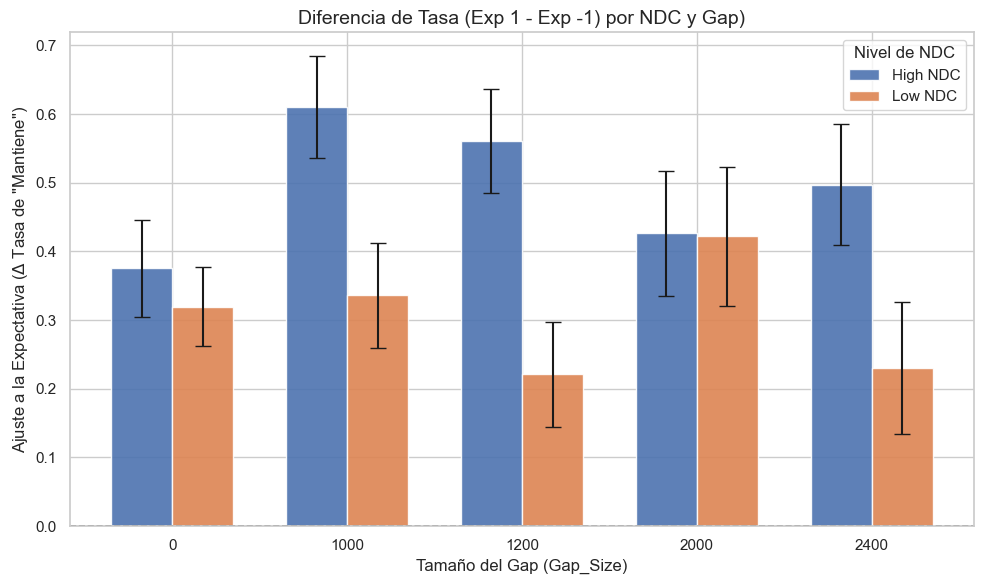

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir los Gaps de tu estudio
gaps = [0, 1000, 1200, 2000, 2400]

# 2. Filtrar y Categorizar usando tus variables exactas
df_plot = df[df['Expectativa_Activa'].isin([1, -1])].copy()
df_plot['Nivel_NDC'] = np.where(df_plot['NDC_Score'] > 4.67, 'High NDC', 'Low NDC')

# 3. Agrupar para calcular Media, Error Estándar (SEM) y N de sujetos únicos
# Asegurate que 'mantiene' es tu columna de 0s y 1s con la decisión
grouped = df_plot.groupby(['Gap_Size', 'Nivel_NDC', 'Expectativa_Activa'])
agg_df = grouped.agg(
    mean_mantiene=('Mantiene', 'mean'),
    sem_mantiene=('Mantiene', 'sem'),
    n_sujetos=('ID_Sujeto', 'nunique') 
).reset_index()

# 4. Pivotear para dejar a la Expectativa 1 y -1 en columnas separadas
pivot_df = agg_df.pivot(index=['Gap_Size', 'Nivel_NDC'], columns='Expectativa_Activa')
pivot_df.columns = [f'{col[0]}_Exp_{col[1]}' for col in pivot_df.columns]
pivot_df = pivot_df.reset_index()

# 5. Calcular la Diferencia y propagar el SEM de ambas medias
pivot_df['Diferencia_Media'] = pivot_df['mean_mantiene_Exp_1'] - pivot_df['mean_mantiene_Exp_-1']
pivot_df['SEM_Diferencia'] = np.sqrt(pivot_df['sem_mantiene_Exp_1']**2 + pivot_df['sem_mantiene_Exp_-1']**2)

# ==========================================
# 6. CREACIÓN DE LA TABLA
# ==========================================
tabla_sujetos = pivot_df[['Gap_Size', 'Nivel_NDC', 'n_sujetos_Exp_1', 'n_sujetos_Exp_-1']].copy()
tabla_sujetos.columns = ['Gap_Size', 'Nivel NDC', 'Sujetos (Exp 1)', 'Sujetos (Exp -1)']
print("--- TABLA DE N (SUJETOS ÚNICOS) ---")
print(tabla_sujetos.to_string(index=False))
# tabla_sujetos.to_csv('tabla_sujetos_diferencia.csv', index=False) # Para guardar

# ==========================================
# 7. GRÁFICO CON BIGOTES DE ERROR (SEM)
# ==========================================
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(gaps)) 
width = 0.35              

high_ndc = pivot_df[pivot_df['Nivel_NDC'] == 'High NDC'].set_index('Gap_Size').reindex(gaps)
low_ndc = pivot_df[pivot_df['Nivel_NDC'] == 'Low NDC'].set_index('Gap_Size').reindex(gaps)

# Dibujar barras. CORRECCIÓN: Se quitó edgecolor='black'
rects1 = ax.bar(x - width/2, high_ndc['Diferencia_Media'], width, label='High NDC', 
                yerr=high_ndc['SEM_Diferencia'], capsize=6, color='#4c72b0', alpha=0.9)
rects2 = ax.bar(x + width/2, low_ndc['Diferencia_Media'], width, label='Low NDC', 
                yerr=low_ndc['SEM_Diferencia'], capsize=6, color='#dd8452', alpha=0.9)

# Formatos. CORRECCIÓN: Tasa de "Mantiene" en el label
ax.set_ylabel('Ajuste a la Expectativa ($\Delta$ Tasa de "Mantiene")', fontsize=12)
ax.set_xlabel('Tamaño del Gap (Gap_Size)', fontsize=12)
ax.set_title('Diferencia de Tasa (Exp 1 - Exp -1) por NDC y Gap)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(gaps)
ax.axhline(0, color='black', linestyle='--', linewidth=1.2)
ax.legend(title='Nivel de NDC')

plt.tight_layout()
plt.show()